In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
english_data = pd.read_csv('data\sentiment_data.csv')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\User\AppData\Local\Temp\ipykernel_19640\2698674452.py:1: SyntaxWarning: invalid escape sequence '\s'
  english_data = pd.read_csv('data\sentiment_data.csv')


In [29]:
english_data.head(10)

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2
5,5,we’ve hounding bank adopt apple pay understand...,1
6,6,got apple pay south africa it’s widely accepted,2
7,7,need apple pay physical credit card,1
8,8,united states abundance retailers accept apple...,2
9,9,cambodia universal qr code system scan send mo...,1


In [30]:
english_data.drop(columns=['Unnamed: 0'], inplace=True)

In [31]:
english_data.shape

(241145, 2)

In [32]:
english_data.head()

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2


## Class Distribution analysis

0 — Negative

1 — Neutral

2 — Positive

<Axes: xlabel='Sentiment'>

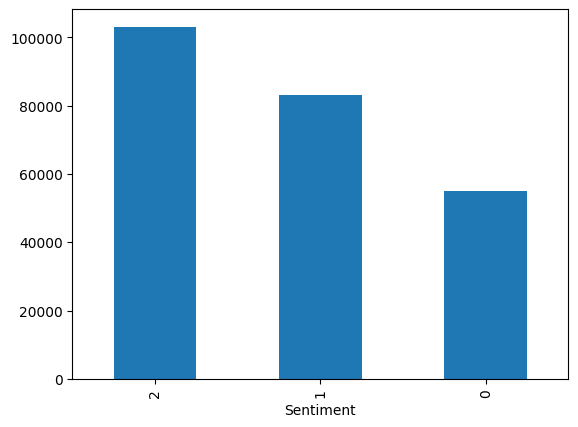

In [33]:
class_count = english_data['Sentiment'].value_counts()
class_count.plot(kind='bar')

## Text length distribution

In [34]:
import nltk 
from nltk.tokenize import word_tokenize

english_data['tokenized_comment'] = english_data['Comment'].apply(lambda x: word_tokenize(str(x)))

english_data.head()

,Comment,Sentiment,tokenized_comment
0,lets forget apple pay required brand new iphon...,1,"[lets, forget, apple, pay, required, brand, ne..."
1,nz retailers don’t even contactless credit car...,0,"[nz, retailers, don, ’, t, even, contactless, ..."
2,forever acknowledge channel help lessons ideas...,2,"[forever, acknowledge, channel, help, lessons,..."
3,whenever go place doesn’t take apple pay doesn...,0,"[whenever, go, place, doesn, ’, t, take, apple..."
4,apple pay convenient secure easy use used kore...,2,"[apple, pay, convenient, secure, easy, use, us..."


In [35]:
english_data['text_length'] = english_data['Comment'].astype(str).str.len()



In [36]:
english_data.head()

,Comment,Sentiment,tokenized_comment,text_length
0,lets forget apple pay required brand new iphon...,1,"[lets, forget, apple, pay, required, brand, ne...",231
1,nz retailers don’t even contactless credit car...,0,"[nz, retailers, don, ’, t, even, contactless, ...",113
2,forever acknowledge channel help lessons ideas...,2,"[forever, acknowledge, channel, help, lessons,...",114
3,whenever go place doesn’t take apple pay doesn...,0,"[whenever, go, place, doesn, ’, t, take, apple...",328
4,apple pay convenient secure easy use used kore...,2,"[apple, pay, convenient, secure, easy, use, us...",93


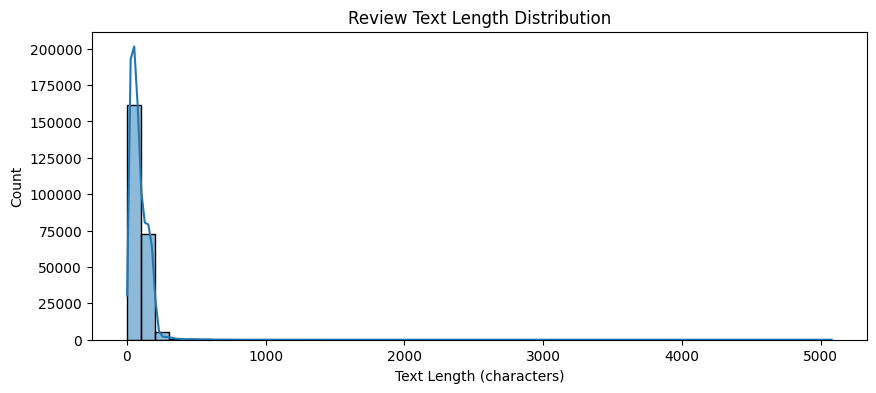

In [37]:
import seaborn as sns   

plt.figure(figsize=(10, 4))
sns.histplot(english_data["text_length"], bins=50, kde=True)
plt.title("Review Text Length Distribution")
plt.xlabel("Text Length (characters)")
plt.show()

## Most frequent words per class

In [38]:
# download the stopwords from nltk


nltk.download('stopwords')
stopwords = set(nltk.corpus.stopwords.words('english'))
print(stopwords)

{'y', 'up', 'at', 'be', 'itself', 'don', 'on', 'because', 'been', "he'd", 'ours', 'only', 'd', 'is', 'mustn', 'you', 'off', 'and', "we'd", "you'll", 'but', 'while', "aren't", 'when', 'o', "she'll", "won't", "needn't", 'further', 'its', 'why', 'doesn', 'about', 'am', "we've", 'between', 'he', 'have', "shan't", 'in', 'before', 'isn', 'i', "it's", "they're", 'wouldn', 'did', 'by', 'shan', 'so', 'own', 'how', 'ourselves', "doesn't", 'needn', 'shouldn', 'as', 'hasn', 'are', 'too', 'not', "he'll", 'themselves', 'into', 'we', 'each', 'which', 'from', 'didn', 'to', 'the', "couldn't", 'theirs', 'who', "you'd", 'his', 'such', "wasn't", 'or', 're', 'can', 'out', 'any', 'himself', 'against', "he's", "we'll", 'above', 'do', "haven't", 'just', 'no', 'this', 'yourself', 'a', 'more', 'them', "i've", "hasn't", 'very', 's', "didn't", 'had', 'that', 'yours', 'her', "we're", "wouldn't", 'through', 'll', 'm', 'some', 'during', 'than', "i'm", 'there', 'both', 'mightn', "you've", 'doing', 'myself', 'with', '

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
punctuation = set('''!()-[]{};:'"\,<>./?@#$%^&*_~''')

english_data['tokenized_comment'] = english_data['tokenized_comment'].apply(lambda tokens: [word for word in tokens if word.lower() not in nltk.corpus.stopwords.words('english') and word not in punctuation])
english_data.head()

<>:1: SyntaxWarning: invalid escape sequence '\,'
<>:1: SyntaxWarning: invalid escape sequence '\,'
C:\Users\User\AppData\Local\Temp\ipykernel_19640\506528491.py:1: SyntaxWarning: invalid escape sequence '\,'
  punctuation = set('''!()-[]{};:'"\,<>./?@#$%^&*_~''')


,Comment,Sentiment,tokenized_comment,text_length
0,lets forget apple pay required brand new iphon...,1,"[lets, forget, apple, pay, required, brand, ne...",231
1,nz retailers don’t even contactless credit car...,0,"[nz, retailers, ’, even, contactless, credit, ...",113
2,forever acknowledge channel help lessons ideas...,2,"[forever, acknowledge, channel, help, lessons,...",114
3,whenever go place doesn’t take apple pay doesn...,0,"[whenever, go, place, ’, take, apple, pay, ’, ...",328
4,apple pay convenient secure easy use used kore...,2,"[apple, pay, convenient, secure, easy, use, us...",93


In [40]:
english_data['tokenized_comment'] = english_data['tokenized_comment'].apply(lambda x: ' '.join(x))
english_data

,Comment,Sentiment,tokenized_comment,text_length
0,lets forget apple pay required brand new iphon...,1,lets forget apple pay required brand new iphon...,231
1,nz retailers don’t even contactless credit car...,0,nz retailers ’ even contactless credit card ma...,113
2,forever acknowledge channel help lessons ideas...,2,forever acknowledge channel help lessons ideas...,114
3,whenever go place doesn’t take apple pay doesn...,0,whenever go place ’ take apple pay ’ happen of...,328
4,apple pay convenient secure easy use used kore...,2,apple pay convenient secure easy use used kore...,93
...,...,...,...,...
241140,crores paid neerav modi recovered congress lea...,0,crores paid neerav modi recovered congress lea...,79
241141,dear rss terrorist payal gawar modi killing pl...,0,dear rss terrorist payal gawar modi killing pl...,223
241142,cover interaction forum left,1,cover interaction forum left,28
241143,big project came india modi dream project happ...,1,big project came india modi dream project happ...,58


In [41]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(english_data['tokenized_comment'])
X.shape

(241145, 152955)

In [42]:
print(english_data['tokenized_comment'].head())

0    lets forget apple pay required brand new iphon...
1    nz retailers ’ even contactless credit card ma...
2    forever acknowledge channel help lessons ideas...
3    whenever go place ’ take apple pay ’ happen of...
4    apple pay convenient secure easy use used kore...
Name: tokenized_comment, dtype: object


## word cloud

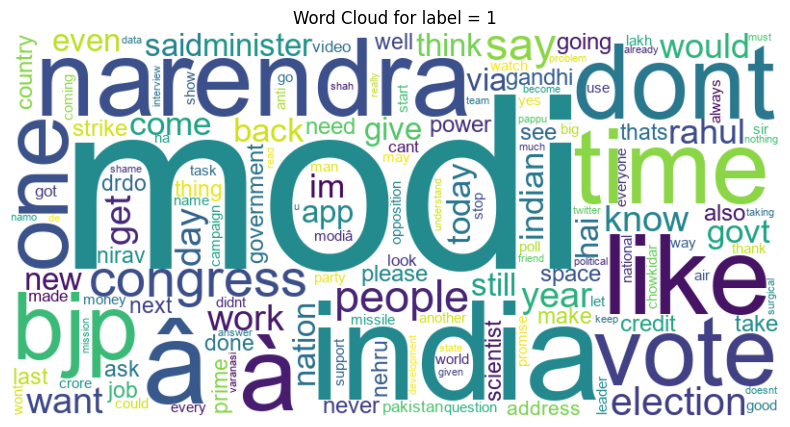

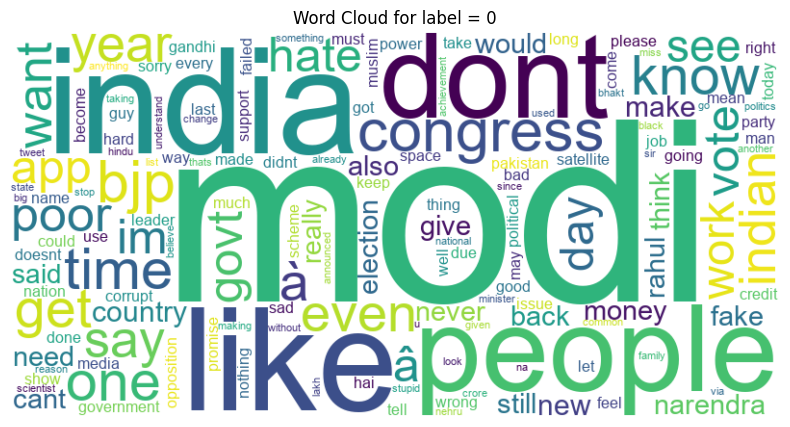

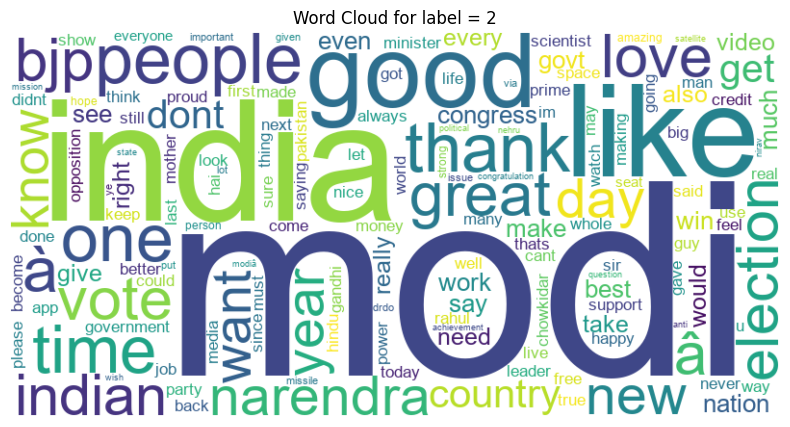

In [43]:
import wordcloud as WC

def make_wordcloud(text, title):

    wc = WC.WordCloud(
        font_path="arial.ttf",
        width=800,
        height=400,
        background_color="white",
        max_words=150,
        stopwords=stopwords,
        collocations=False,
    ).generate(text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

for label in english_data["Sentiment"].unique():
    texts = english_data.loc[english_data["Sentiment"] == label, "tokenized_comment"].astype(str)
    texts = texts.sample(3000, random_state=42)
    texts = " ".join(texts)
    make_wordcloud(texts, f"Word Cloud for label = {label}")

## Feature extraction ( using TF-IDF ) 

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
english_vectorizer = TfidfVectorizer()
X = english_vectorizer.fit_transform(english_data['tokenized_comment'])
X.shape

(241145, 152955)

In [45]:
from sklearn.model_selection import train_test_split
y = english_data['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(english_data['tokenized_comment'], y, test_size=0.2, random_state=42)

english_vectorizer = TfidfVectorizer()
X_train_tfidf = english_vectorizer.fit_transform(X_train)
X_test_tfidf = english_vectorizer.transform(X_test)

In [46]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(192916, 133360)
(48229, 133360)


## Model Training using Gaussian Naïve Bayes 

In [47]:
from sklearn.naive_bayes import MultinomialNB

english_model = MultinomialNB()

english_model.fit(X_train_tfidf, y_train)
y_pred = english_model.predict(X_test_tfidf)    

In [48]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.22      0.35     11089
           1       0.74      0.38      0.50     16502
           2       0.53      0.95      0.68     20638

    accuracy                           0.59     48229
   macro avg       0.72      0.52      0.51     48229
weighted avg       0.68      0.59      0.54     48229



In [49]:
from sklearn.linear_model import LogisticRegression

english_modelLG = LogisticRegression()
english_modelLG.fit(X_train_tfidf, y_train)
y_pred_LG = english_modelLG.predict(X_test_tfidf)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
print("Classification Report:")
print(classification_report(y_test, y_pred_LG))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.65      0.72     11089
           1       0.75      0.83      0.79     16502
           2       0.83      0.83      0.83     20638

    accuracy                           0.79     48229
   macro avg       0.79      0.77      0.78     48229
weighted avg       0.79      0.79      0.79     48229



In [51]:
english_data['language'] = 'English'

In [52]:
import pickle
pickle.dump(english_model, open("models/english_model.pkl", "wb"))
pickle.dump(english_vectorizer, open("victorizers/english_vectorizer.pkl", "wb"))